In [1]:
### 1. 기본 데이터 처리 및 시각화
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 및 마이너스 기호 처리
plt.rc("font", family="Malgun Gothic") # Mac: AppleGothic
plt.rcParams["axes.unicode_minus"] = False


### 2. 데이터 전처리 및 분석
from scipy.stats import spearmanr, pearsonr
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PolynomialFeatures
from imblearn.over_sampling import SMOTE


### 3. 머신러닝 모델 (회귀 - Regressor)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor, 
    ExtraTreesRegressor, 
    GradientBoostingRegressor, 
    HistGradientBoostingRegressor
)
from xgboost import XGBRegressor


### 4. 머신러닝 모델 (분류 - Classifier)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    ExtraTreesClassifier, 
    GradientBoostingClassifier, 
    HistGradientBoostingClassifier
)
from xgboost import XGBClassifier


### 5. 모델 평가 지표
# 회귀 평가
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 분류 평가
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

# 모델 저장
import joblib

In [2]:
# SAS 파일 읽기
file_path14 = './datas/hn14_all.sas7bdat'
file_path15 = './datas/hn15_all.sas7bdat'
file_path16 = './datas/hn16_all.sas7bdat'
file_path17 = './datas/hn17_all.sas7bdat'
file_path18 = './datas/hn18_all.sas7bdat'
file_path19 = './datas/hn19_all.sas7bdat'
file_path20 = './datas/hn20_all.sas7bdat'
file_path21 = './datas/hn21_all.sas7bdat'
file_path22 = './datas/hn22_all.sas7bdat'
file_path23 = './datas/hn23_all.sas7bdat'
file_path24 = './datas/hn24_all.sas7bdat'

df14 = pd.read_sas(file_path14, format='sas7bdat', encoding='latin1') 
df15 = pd.read_sas(file_path15, format='sas7bdat', encoding='latin1') 
df16 = pd.read_sas(file_path16, format='sas7bdat', encoding='latin1') 
df17 = pd.read_sas(file_path17, format='sas7bdat', encoding='latin1') 
df18 = pd.read_sas(file_path18, format='sas7bdat', encoding='latin1') 
df19 = pd.read_sas(file_path19, format='sas7bdat', encoding='latin1') 
df20 = pd.read_sas(file_path20, format='sas7bdat', encoding='latin1') 
df21 = pd.read_sas(file_path21, format='sas7bdat', encoding='latin1') 
df22 = pd.read_sas(file_path22, format='sas7bdat', encoding='latin1') 
df23 = pd.read_sas(file_path23, format='sas7bdat', encoding='latin1') 
df24 = pd.read_sas(file_path24, format='sas7bdat', encoding='latin1') 



In [3]:
# 1. 모든 데이터프레임을 리스트로 묶습니다.
df_list = [df14, df15, df16, df17, df18, df19, df20, df21, df22, df23, df24]

# 2. 한 번에 위아래로 합칩니다.
# ignore_index=True를 주면 인덱스가 0부터 새로 정렬되어 깔끔합니다.
df_total = pd.concat(df_list, ignore_index=True)

In [4]:
### "DI4_dg","DI5_dg" 이 두개 컬럼을 종속변수로 둠
# DI4_dg = 심근경색증 또는 혐심증 의사 진단 여부(0.없음, 1.있음, 8.비해당)
# DI5_dg = 심근경색증 의사 진단 여부(0.없음, 1.있음, 8.비해당, 9.모름, 무응답)

data = df_total[["DI4_dg", "DI5_dg", "DI1_dg", "DI2_dg", "DE1_dg", "DI3_dg", "HE_HP",  "HE_glu", "HE_HbA1c", "HE_chol", "HE_TG", "HE_BMI", "HE_wc",
               "BS1_1", "BD1_11", "BD2_1", "BE8_1", "pa_aerobic",
               "sex", "age", "edu", "ho_incm"]]


In [7]:
# DI1_dg (고혈압 진단여부)(0. 없음1. 있음8. 비해당(소아, 청소년)9. 모름, 무응답)
# ------> 8을 0으로 바꿈 9의 데이턴는 삭제
# DI2_dg  (이상지질혈증 의사진단)(0. 없음1. 있음8. 비해당(소아, 청소년)9. 모름, 무응답)
# ------> 8을 0으로 바꿈 9의 데이턴는 삭제
# DE1_dg  (당뇨병 의사진단 여부)(0. 없음1. 있음8. 비해당(소아, 청소년)9. 모름, 무응답)
# ------> 8을 0으로 바꿈 9의 데이턴는 삭제
# DI3_dg (뇌졸중 의사 진단 여부)(0, 1, 8, 9)
# ------> 8을 0으로 바꿈 9의 데이턴는 삭제
# HE_HP (고혈압 유병여부) (1정상, 2주의혈압 3고혈압전단계 4고혈압)
# HE_glu (공복혈당)
# HE_HbA1c  (당화혈색소)
# HE_chol (총콜레스테롤)
# HE_TG (중성지방)
# HE_BMI  (체질량지수)
# HE_wc  (복부비만/허리둘레)
# BS1_1 = 평생 일반담배 흡연 여부(1.5갑 미만, 2.5갑 이상, 3.피운적없음, 8.비해당, 9.모름,무응답 )
# BD1_11  (1년간 음주 빈도)(1. 최근 1년간 전혀 마시지 않았다2. 월1회미만3. 월1회정도4. 월2-4회5. 주2-3회정도6. 주4회이상8. 비해당(문항1-①⑧)9. 모름, 무응답)
# ------> 8을 1으로 바꿈 9의 데이턴는 삭제
# BD2_1  (한번에 마시는 음주량)(1. 1-2잔2. 3-4잔3. 5-6잔4. 7-9잔5. 10잔 이상8. 비해당(문항2-1-①⑧)9. 모름, 무응답)
# ------> 9의 데이턴는 삭제
# PA_aerobic 유산소 신체활동 실천율 (0. 일주일에 중강도 신체활동을 2시간 30분 이상 또는 고강도 신체활동을 1시간 15분 이상 또는 중강도와 고
# 강도 신체활동을 섞어서(고강도 1분은 중강도 2분) 각 활동에 상당하는 시간을 실천하지 않음1. 일주일에 중강도 신체활동을 2시간 
# 30분 이상 또는 고강도 신체활동을 1시간 15분 이상 또는 중강도와 고강도 신체활동을 섞어서(고강도 1분은 중강도 2분) 각 활동에 상당하는 시간을 실천)
# BE8_1  (앉아서 보내는 시간)(□□시간88. 비해당(소아)99. 모름, 무응답)
# sex 
# age 
# edu  (교육수준) (1. 초졸이하2. 중졸3. 고졸4. 대졸이상)
# ho_incm = 소득 사분위수 (가구)(1.하, 2.중하, 3.중상, 4.상)

In [8]:
# HE_HP = 고혈압 유병 여부(1.정상, 2.주의혈압, 3. 고혈압전단계, 4.고혈압 )
# HE_chol = 총콜레스테롤
# HE_HDL_st2 = HDL-콜레스테롤
# HE_TG = 중성지방
# HE_LDL_drct = LDL-콜레스테롤(직접검사)
# HE_HCHOL = 고콜레스테롤혈증 유병 여부(0.없음, 1.있음)
# DI2_2 = 이상지질혈증 치료여부
# HE_HTG = 고중성지방혈증 유병여부
# BS3_1 = 현재 흡연 여부 (1.매일피움, 2.가끔피움, 3.과거엔피웠으나, 현재 피우지않음, 8.비해당, 9.모름, 무응답)
# BS3_2 = 하루 평균 일반담배 흡연량
# BS1_1 = 평생 일반담배 흡연 여부(1.5갑 미만, 2.5갑 이상, 3.피운적없음, 8.비해당, 9.모름,무응답 )
# BS8_2 = 직장실내 간접흡연 노출 여부(1.예, 2.아니오, 8.비해당, 9.모름,무응답)
# BS9_2 = 가정실내 간접흡연 노출 여부(1.예, 2.아니오, 3.본인을 제외한가종중 가정의 실내에서 담배를 피우는사람없음, 8.비해당, 9.모름, 무응답)
# HE_glu = 공복혈당 
# HE_HbA1c = 당화혈색소
# HE_DM_HbA1c = 당뇨병 유병여부(1.정상, 2.당뇨병 전단계, 3.당뇨병)
# DE1_dg = 당뇨병 의사진단 여부(0.없음, 1.있음, 8.비해당, 9.모름, 무응답)
# DE1_pt = 당뇨병 치료(0. 없음, 1.있음, 8.비해당, 9.모름, 무응답)
# DE1_31 = 당뇨병 혈당관리 치료 : 인슐린 주사
# DE1_32 = 당뇨병 혈당관리 치료 : 당뇨병약
# HE_BMI = 체질량 지수 
# HE_obe = 비만 유병여부 (1.저체중, 2.정상, 3.비만전단계, 4.1단계비만, 5.2단계비만, 6.3단계비만)
# HE_wc = 복부비만
# BIA_BFM = 체지방량
# BIA_PBF = 체지방률
# BIA_FT = 몸통체지방량
# HE_IHDfh1 = 허혈성심장진환 의사진단 여부(부)
# HE_IHDfh1 = 허혈성심장진환 의사진단 여부(모)
# HE_IHDfh3 = 허형성심장진환 의사진단 여부(형제 자매)
# HE_HPfh1 = 고혈압 의사진단 여부(부)
# HE_HPfh2 = 고혈압 의사진단 여부(모)
# HE_HPfh3 = 고혈압 의사진단 여부(형제 자매)
# HE_DMfh1 = 당뇨병 의사진단 여부(부)
# HE_DMfh1 = 당뇨병 의사진단 여부(모)
# HE_DMfh1 = 당뇨병 의사진단 여부(형제 자매)
# HE_HLfh1 = 고지혈증 의사진단 여부(부)
# HE_HLfh1 = 고지혈증 의사진단 여부(모)
# HE_HLfh1 = 고지혈증 의사진단 여부(형제 자매)
# HE_hsCRP = 고감도 C반응단백
# HE_WBC = 백혈구수
# HE_Bplt = 혈소판수
# HE_Uacid = 요산
# HE_HB = 헤모글로빈
# HE_anem = 빈혈 유병 여부(0.없음, 1.있음)
# HE_rPLS = 맥박 규칙성(부정맥 선별, 1.규칙적, 2.불규칙적)
# HE_mPLS = 60초 맥박수
# BD1_11 = 1년간 음주 빈도(1. 1년간 전혀안마심, 2. 월1회미만, 3. 월1회정도, 4. 월2~4회, 5. 주 2~3회정도, 6. 주4회이상, 8.비해당, 9.모름, 무응답)
# BD2_1 = 한번에 마시는 음주량(1. 1~2잔, 2.3~4잔, 3.5~6잔, 4.7~9잔, 5.10잔이상, 8.비해당, 9.무응답, 모름)
# BD2_31 = 폭음빈도(1. 전혀없음, 2.월1회미만, 3. 월1회정도, 4. 주1회정도, 5.거의매일, 8.비해당, 9.모름, 무응답)
# BD2_32 = 폭음빈도-여성(1. 전혀없음, 2.월1회미만, 3. 월1회정도, 4. 주1회정도, 5.거의매일, 8.비해당, 9.모름, 무응답)
# HE_BUN = 혈중요소질소
# HE_crea = 혈중크레아티닌
# HE_Ualb = 요알부민(미세알부민뇨-> 심혈관 위험)
# DN1_dg = 콩팥병 의사진단 여부(0. 없음, 1.있음, 8.비해당, 9.모름, 무응답)
## PA_aerobic = 유산소 신체활동 실천율 (0. 일주일에 중강도 신체활동을 2시간 30분 이상 또는 고강도 신체활동을 1시간 15분 이상 또는 중강도와 고
# 강도 신체활동을 섞어서(고강도 1분은 중강도 2분) 각 활동에 상당하는 시간을 실천하지 않음1. 일주일에 중강도 신체활동을 2시간 
# 30분 이상 또는 고강도 신체활동을 1시간 15분 이상 또는 중강도와 고강도 신체활동을 섞어서(고강도 1분은 중강도 2분) 각 활동에 상당하는 시간을 실천)
# BE3_31 = 일주일간 걷기 일수 (1. 전혀 하지 않음2. 1일3. 2일4. 3일5. 4일6. 5일7. 6일8. 7일(매일)88. 비해당(소아, 청소년)99. 모름, 무응답)
# BE3_33 = 걷기 지속 시간
# BE5_1 = 일주일간 근력운동 일수(1. 전혀 하지 않음2. 1일3. 2일4. 3일5. 4일6. 5일이상8. 비해당(소아)9. 모름, 무응답)
## BP16_1 = 주중 하루 평균 수면 시간
## BP16_2 = 주말 하루 평균 수면 시간
## BP17_2 = 폐쇄성수면무호흡증 위험요인 : 코골이(1.예, 2.아니오, 8.비해당, 9.모름, 무응답)
## BP17_3 = 폐쇄성수면무호흡증 위험요인 : 피곤함(1.예, 2.아니오, 8.비해당, 9.모름, 무응답)
## BP17_dg = 폐쇄성수면무호흡증 의사진단 여부(1.예, 2.아니오, 8.비해당, 9.모름, 무응답)
# BP1 = 평소 스트레스 인지정도(1. 대단히 많이 느낀다2. 많이 느끼는 편이다3. 조금 느끼는 편이다4. 거의 느끼지 않는다8. 비해당(소아)9. 모름, 무응)
# BP5 = 2주이상 연속 우울감 여부(1. 예2. 아니오8. 비해당(소아)   ※’22, ’24년: 비해당(성인, 소아)9. 모름, 무응답)
# HE_D2 = 비타민D (결핍 시 심혈관 위험↑)
# HE_Mg = 마그네슘 (결핍 시 부정맥·혈압↑)
# HE_Ca = 칼슘
# LW_ms = 폐경 여부 및 상태(1. 초경하기 전2. 월경중3. 임신중4. 출산후 수유 중5. 자연폐경6. 인공폐경7. 기타8. 비해당(10세미만 여자)9. 모름, 무응답)
# LW_mp_a = 폐경 나이(조기폐경 → 심혈관 위험↑)
# LW_wh = 여성호르몬제 복용경험(1.예, 2.아니오, 8.비해당, 9.모름, 무응답)
# LW_wh = 폐경 후 여성호르몬제(HRT) 복용 여부
# sex = 
# age
# edu = 교육수준(1. 초졸이하2. 중졸3. 고졸4. 대졸이상)
# incm = 소득분위(1. 하2. 중하3. 중상4. 상)
# occp = 직업(육체노동 스트레스 직종)(1. 관리자, 전문가 및 관련 종사자2. 사무종사자3. 서비스 및 판매 종사자4. 농림어업 숙련 종사자
# 5. 기능원, 장치․기계조작 및 조립종사자6. 단순노무종사자7. 무직(주부, 학생 등))
# EC_wht_5 = 교대근무 여부(1. 주간 근무2. 저녁 근무(pm14:00~24:00)3. 밤 근무(pm21:00~익일 am8:00)4. 주야간 규칙적 교대 근무5. 24시간 교대 근무
# 6. 분할 근무(하루 근무시간대 2개이상)7. 불규칙 교대 근무8. 기타88. 비해당(최근 1년 동안 일을 하지 않음)99. 모름, 무응답)
# BE3_91 = 신체활동 여부 : 장소이동 (1.예, 2.아니오, 8.비해당, 9.무응답, 모름)
# BE8_1 = 하루에 앉아서 보내는 시간
#  ho_incm = 소득 사분위수 (가구)(1.하, 2.중하, 3.중상, 4.상)






In [5]:
# ------> 8을 0으로 바꿈 9의 데이턴는 삭제
col_replace = ["DI1_dg", "DI2_dg", "DE1_dg", "DI3_dg"]
# ------> 8을 1으로 바꿈 9의 데이턴는 삭제
col_replace2 = ["BD1_11"]
# ------> 9의 데이턴는 삭제
col_replace3 = ["BD2_1"]

for col in col_replace:
    if col in data.columns:
        # 비해당 → 0
        data[col] = data[col].replace(8, 0)
        # 모름/무응답 → 행 삭제
        data = data[data[col] != 9]      

for col in col_replace2:
    if col in data.columns:
        data[col] = data[col].replace(8, 1)
        data = data[data[col] != 9]
data = data[data["BD2_1"] != 9]

C:\Users\Administrator\AppData\Local\Temp\ipykernel_18760\2979254233.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = data[col].replace(8, 0)


In [6]:
data = data.dropna()

In [12]:
target = data["DI4_dg"]
datas = data[["DI1_dg", "DI2_dg", "DE1_dg", "DI3_dg", "HE_HP",  "HE_glu", "HE_HbA1c", "HE_chol", "HE_TG", "HE_BMI", "HE_wc",
               "BS1_1", "BD1_11", "BD2_1", "BE8_1", "pa_aerobic",
               "sex", "age", "edu", "ho_incm"]]

In [13]:
X = datas
y = target

In [66]:
correlatation_matrix = X.corr(numeric_only=True)

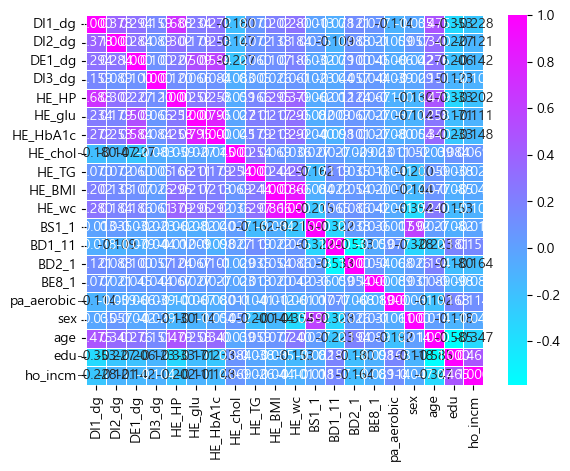

In [15]:
sns.heatmap(correlatation_matrix, annot=True, cmap="cool", fmt=".3f", linewidths=0.5)
plt.show()

In [16]:
for i in X.columns:
    a, b = spearmanr(X[i], y)
    if b < 0.05 :
        print(f"독립변수({i})와 종속변수(BDI)의 상관관계 계수는 {round(a, 3)}이고, p-value의 값은 {round(b, 3)}임 따라서 p-value < 0.05 이므로 유의미함")
    else :
        print(f"독립변수({i})와 종속변수(BDI)의 상관관계 계수는 {round(a, 3)}이고, p-value의 값은 {round(b, 3)}임 따라서 p-value >= 0.05 이므로 유의미하지않음")
    

독립변수(DI1_dg)와 종속변수(BDI)의 상관관계 계수는 0.138이고, p-value의 값은 0.0임 따라서 p-value < 0.05 이므로 유의미함
독립변수(DI2_dg)와 종속변수(BDI)의 상관관계 계수는 0.13이고, p-value의 값은 0.0임 따라서 p-value < 0.05 이므로 유의미함
독립변수(DE1_dg)와 종속변수(BDI)의 상관관계 계수는 0.113이고, p-value의 값은 0.0임 따라서 p-value < 0.05 이므로 유의미함
독립변수(DI3_dg)와 종속변수(BDI)의 상관관계 계수는 0.075이고, p-value의 값은 0.0임 따라서 p-value < 0.05 이므로 유의미함
독립변수(HE_HP)와 종속변수(BDI)의 상관관계 계수는 0.107이고, p-value의 값은 0.0임 따라서 p-value < 0.05 이므로 유의미함
독립변수(HE_glu)와 종속변수(BDI)의 상관관계 계수는 0.089이고, p-value의 값은 0.0임 따라서 p-value < 0.05 이므로 유의미함
독립변수(HE_HbA1c)와 종속변수(BDI)의 상관관계 계수는 0.132이고, p-value의 값은 0.0임 따라서 p-value < 0.05 이므로 유의미함
독립변수(HE_chol)와 종속변수(BDI)의 상관관계 계수는 -0.137이고, p-value의 값은 0.0임 따라서 p-value < 0.05 이므로 유의미함
독립변수(HE_TG)와 종속변수(BDI)의 상관관계 계수는 0.019이고, p-value의 값은 0.0임 따라서 p-value < 0.05 이므로 유의미함
독립변수(HE_BMI)와 종속변수(BDI)의 상관관계 계수는 0.048이고, p-value의 값은 0.0임 따라서 p-value < 0.05 이므로 유의미함
독립변수(HE_wc)와 종속변수(BDI)의 상관관계 계수는 0.089이고, p-value의 값은 0.0임 따라서 p-value < 0.05 이므로 유의미함
독립변수(BS1_1)와 종속변수(BDI)의 상관관계 계수는

In [17]:
# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
X_train.to_numpy()
X_test.to_numpy()
y_train.to_numpy()
y_test.to_numpy()
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(37509, 20) (9378, 20)
(37509,) (9378,)


In [19]:
ss = StandardScaler()
ss.fit(X_train)
X_train_scale = ss.transform(X_train)
X_test_scale = ss.transform(X_test)

print(X_train_scale.shape, X_test_scale.shape)


(37509, 20) (9378, 20)


In [20]:
### 1. 훈련모델 생성하기(독립변수 특성이 3개 이상이므로, 다중회귀모델이 적용됨)
lr = LinearRegression()

### 2. 훈련 시키기
lr.fit(X_train_scale, y_train)

### 3. 훈련, 검증 데이터 정확도 확인(과적합 여부 확인)
lr_train_score = lr.score(X_train_scale, y_train)


### 4. 훈련, 검증, 테스트 데이터로 예측하기
lr_train_pred = lr.predict(X_train_scale)
lr_test_pred = lr.predict(X_test_scale)

### 5. 훈련, 검증, 테스트 평가하기(모델 사용 가능 여부 확인)
# - 평가는 평균절대오차 함수와 동일하게 평균제곱오차와 결정계수 모두 함수에 넣는 값 동일
train_mae = mean_absolute_error(y_train, lr_train_pred)
train_mse = mean_squared_error(y_train, lr_train_pred)
train_r2 = r2_score(y_train, lr_train_pred)
test_mae = mean_absolute_error(y_test, lr_test_pred)
test_mse = mean_squared_error(y_test, lr_test_pred)
test_r2 = r2_score(y_test, lr_test_pred)
print(f"훈련 mae : {train_mae:.4f} mse : {train_mse:.4f} r2 : {train_r2:.4f}")
print(f"테스트 mae : {test_mae:.4f} mse : {test_mse:.4f} r2 : {test_r2:.4f}")

훈련 mae : 0.0611 mse : 0.0264 r2 : 0.0594
테스트 mae : 0.0643 mse : 0.0295 r2 : 0.0607


In [63]:
# 1. SMOTE로 데이터 뻥튀기 (훈련 데이터에만 적용해야 함!)
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scale, y_train)


In [64]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import average_precision_score
import numpy as np

# 클래스 비율 계산
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 모델 생성
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4,
    eval_metric='logloss',
    random_state=42
)

# 학습
model.fit(X_train_scale, y_train)

# 확률 예측
lr_test_pred = model.predict(X_test_scale)
y_probs = model.predict_proba(X_test_scale)[:, 1]

thresholds = [0.4, 0.5, 0.6, 0.7]

for th in thresholds:
    y_pred = (y_probs >= th).astype(int)

    print(f"\n===== Threshold: {th} =====")
    print(classification_report(y_test, y_pred))

# PR-AUC
ap = average_precision_score(y_test, y_probs)
print("PR-AUC:", ap)


===== Threshold: 0.4 =====
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97      9074
         1.0       0.20      0.28      0.24       304

    accuracy                           0.94      9378
   macro avg       0.59      0.62      0.60      9378
weighted avg       0.95      0.94      0.95      9378


===== Threshold: 0.5 =====
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      9074
         1.0       0.26      0.15      0.19       304

    accuracy                           0.96      9378
   macro avg       0.61      0.57      0.58      9378
weighted avg       0.95      0.96      0.95      9378


===== Threshold: 0.6 =====
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      9074
         1.0       0.36      0.05      0.09       304

    accuracy                           0.97      9378
   macro avg       0.66      0.52      0.54 

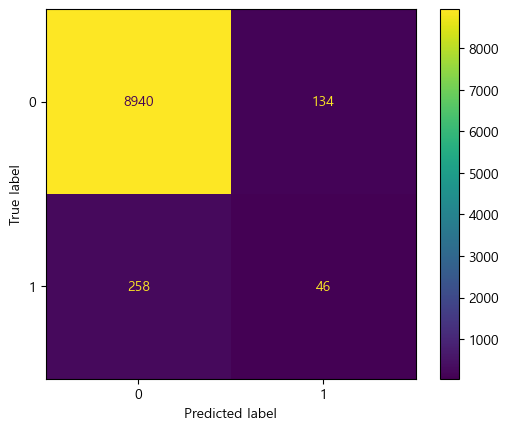

In [65]:
# 1차 그냥모델만 
# 2차 somte로 데이터 늘리기
# 3차 smote + scale_pos_weight 추가


# 오차행렬 계산
cm = confusion_matrix(y_test, lr_test_pred)

# 오차행렬 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
disp.plot()
plt.show()

In [69]:
# BMI 수치 구간화
data['BMI_group'] = pd.cut(
    data['HE_BMI'],
    bins=[0, 18.5, 23, 25, 30, 100],
    labels=[0,1,2,3,4]
)

In [70]:
# BMI와 허리둘레 곱한 값
data['BMI_WC'] = data['HE_BMI'] * data['HE_wc']

In [71]:
# 혈당 위험도 변수
data['glu_risk'] = pd.cut(
    data['HE_glu'],
    bins=[0,100,126,1000],
    labels=[0,1,2]
)

In [72]:
# 당화혈 색소
data['hba1c_risk'] = pd.cut(
    data['HE_HbA1c'],
    bins=[0,5.7,6.5,20],
    labels=[0,1,2]
)

In [73]:
# 고혈합여부 (0,1로 바꾸기)
data['high_bp'] = (data['HE_HP'] >= 3).astype(int)

In [74]:
# 술담배 함치기
data['smoke_drink'] = data['BS1_1'] * data['BD1_11']

In [75]:
#대사증후군 점수 비만, 고혈압, 고혈당, 중성지방 높음
data['metabolic_score'] = (
    (data['HE_BMI'] >= 25).astype(int) +
    (data['HE_glu'] >= 100).astype(int) +
    (data['HE_TG'] >= 150).astype(int) +
    (data['HE_HP'] >= 3).astype(int)
)

In [76]:
# 나이 구간화
data['age_group'] = pd.cut(
    data['age'],
    bins=[0,30,40,50,60,70,100],
    labels=[0,1,2,3,4,5]
)

In [77]:
# 콜레스테롤/중성지방 비율
data['chol_tg_ratio'] = (
    data['HE_chol'] / (data['HE_TG'] + 1)
)

In [78]:
# 생활습관 위험 점수
data['lifestyle_risk'] = (
    (data['BS1_1'] == 2).astype(int) +
    (data['BD1_11'] >= 5).astype(int) +
    (data['pa_aerobic'] == 0).astype(int)
)

In [91]:
# 대사질환 핵심점수======
data['metabolic_score'] = (
    (data['HE_BMI'] >= 25).astype(int) +
    (data['HE_glu'] >= 100).astype(int) +
    (data['HE_HbA1c'] >= 5.7).astype(int) +
    (data['HE_TG'] >= 150).astype(int) +
    (data['HE_wc'] >= 90).astype(int)
)

In [92]:
# 당뇨 핵심 점수
data['diabetes_risk'] = (
    (data['HE_glu'] >= 100).astype(int) +
    (data['HE_HbA1c'] >= 5.7).astype(int) +
    (data['HE_BMI'] >= 25).astype(int)
)

In [93]:
# 심혈관 위험 점수
data['cv_risk'] = (
    (data['DI1_dg'] == 1).astype(int) +
    (data['HE_HP'] >= 3).astype(int) +
    (data['HE_chol'] >= 240).astype(int) +
    (data['HE_TG'] >= 150).astype(int)
)

In [94]:
# 생활습관 점수
data['lifestyle_risk'] = (
    (data['BS1_1'] != 3).astype(int) +   # 흡연 경험
    (data['BD1_11'] >= 5).astype(int) +  # 잦은 음주
    (data['pa_aerobic'] == 0).astype(int)
)

In [95]:
# 나이기반 강화
data['age_risk'] = pd.cut(
    data['age'],
    bins=[0, 30, 40, 50, 60, 70, 100],
    labels=[0,1,2,3,4,5]
)

In [96]:
# 비만 + 복부비만 결합
data['obesity_combo'] = (
    (data['HE_BMI'] >= 25).astype(int) +
    (data['HE_wc'] >= 90).astype(int)
)

In [97]:
# 혈당 로그 + 비선형 변환
data['glu_log'] = np.log1p(data['HE_glu'])
data['tg_log'] = np.log1p(data['HE_TG'])

In [98]:
# interaction features
data['glu_bmi'] = data['HE_glu'] * data['HE_BMI']
data['age_glu'] = data['age'] * data['HE_glu']
data['wc_bmi'] = data['HE_wc'] * data['HE_BMI']

In [99]:
# 총 위험 점수
data['total_risk_score'] = (
    data['metabolic_score'] +
    data['lifestyle_risk'] +
    data['cv_risk']
)

In [100]:
data

,DI4_dg,DI5_dg,DI1_dg,DI2_dg,DE1_dg,DI3_dg,HE_HP,HE_glu,HE_HbA1c,HE_chol,...,diabetes_risk,cv_risk,age_risk,obesity_combo,glu_log,tg_log,glu_bmi,age_glu,wc_bmi,total_risk_score
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,96.0,5.4,184.0,...,1,0,0,1,4.574711,4.510860,2778.226348,2880.0,2370.174353,1
2,0.0,0.0,0.0,0.0,0.0,0.0,2.0,98.0,5.3,191.0,...,1,0,0,1,4.595120,4.859812,2808.651411,2842.0,2450.405057,1
3,0.0,0.0,1.0,0.0,1.0,0.0,3.0,141.0,7.5,133.0,...,2,2,4,0,4.955827,4.394449,2846.541546,9165.0,1433.364892,5
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,96.0,5.5,168.0,...,0,0,3,0,4.574711,4.521789,1864.468185,5472.0,1229.383710,0
5,0.0,0.0,0.0,0.0,0.0,0.0,2.0,90.0,5.3,148.0,...,0,0,4,0,4.510860,4.094345,2173.131781,5940.0,2028.256328,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81944,0.0,0.0,0.0,1.0,0.0,1.0,2.0,88.0,5.1,182.0,...,0,0,4,0,4.488636,3.828641,1570.129327,5720.0,1168.675806,1
81945,0.0,0.0,1.0,0.0,1.0,0.0,4.0,116.0,6.6,165.0,...,2,2,5,0,4.762174,4.553877,1979.233424,9280.0,1132.940512,5
81946,0.0,0.0,1.0,1.0,1.0,0.0,4.0,136.0,7.9,132.0,...,3,2,5,2,4.919981,4.672829,4206.499688,10880.0,3021.875144,7
81947,0.0,0.0,1.0,0.0,0.0,0.0,4.0,107.0,5.6,188.0,...,1,3,5,0,4.682131,5.023881,2529.159756,8560.0,2075.329220,7


In [101]:
target = data["DI4_dg"]
datas = data[["DI1_dg", "DI2_dg", "DE1_dg", "DI3_dg", "HE_HP",  "HE_glu", "HE_HbA1c", "HE_chol", "HE_TG", "HE_BMI", "HE_wc",
               "BS1_1", "BD1_11", "BD2_1", "BE8_1", "pa_aerobic",
               "sex", "age", "edu", "ho_incm",'lifestyle_risk','chol_tg_ratio','age_group','metabolic_score','smoke_drink',
              'high_bp','hba1c_risk','glu_risk','BMI_WC', 'BMI_group','total_risk_score','wc_bmi','age_glu','glu_bmi','tg_log',
              'glu_log','obesity_combo','age_risk','lifestyle_risk', 'cv_risk', 'diabetes_risk', 'metabolic_score']]

In [102]:
X = datas
y = target
X_train.to_numpy()
X_test.to_numpy()
y_train.to_numpy()
y_test.to_numpy()
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)
ss = StandardScaler()
ss.fit(X_train)
X_train_scale = ss.transform(X_train)
X_test_scale = ss.transform(X_test)

print(X_train_scale.shape, X_test_scale.shape)

# 1. SMOTE로 데이터 뻥튀기 (훈련 데이터에만 적용해야 함!)
# smote = SMOTE(sampling_strategy=0.2, random_state=42)
# X_train_res, y_train_res = smote.fit_resample(X_train_scale, y_train)

# 클래스 비율 계산
# scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 모델 생성
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4,
    eval_metric='logloss',
    random_state=42
)

# 학습
model.fit(X_train_scale, y_train)

# 확률 예측
lr_test_pred = model.predict(X_test_scale)
y_probs = model.predict_proba(X_test_scale)[:, 1]

thresholds = [0.4, 0.5, 0.6, 0.7]

for th in thresholds:
    y_pred = (y_probs >= th).astype(int)

    print(f"\n===== Threshold: {th} =====")
    print(classification_report(y_test, y_pred))

# PR-AUC
ap = average_precision_score(y_test, y_probs)
print("PR-AUC:", ap)

(37509, 20) (9378, 20)
(37509,) (9378,)
(37509, 20) (9378, 20)

===== Threshold: 0.4 =====
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97      9074
         1.0       0.20      0.28      0.24       304

    accuracy                           0.94      9378
   macro avg       0.59      0.62      0.60      9378
weighted avg       0.95      0.94      0.95      9378


===== Threshold: 0.5 =====
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      9074
         1.0       0.26      0.15      0.19       304

    accuracy                           0.96      9378
   macro avg       0.61      0.57      0.58      9378
weighted avg       0.95      0.96      0.95      9378


===== Threshold: 0.6 =====
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      9074
         1.0       0.36      0.05      0.09       304

    accuracy                       

In [104]:
file_path13 = "./datas/hn13_all.sas7bdat"
file_path12 = "./datas/hn12_all.sas7bdat"
file_path11 = "./datas/hn11_all.sas7bdat"
file_path10 = "./datas/hn10_all.sas7bdat"
file_path9 = "./datas/hn09_all.sas7bdat"
file_path8 = "./datas/hn08_all.sas7bdat"
file_path7 = "./datas/hn07_all.sas7bdat"
file_path5 = "./datas/hn05_all.sas7bdat"

df13 = pd.read_sas(file_path13, format='sas7bdat', encoding='latin1') 
df12 = pd.read_sas(file_path12, format='sas7bdat', encoding='latin1') 
df11 = pd.read_sas(file_path11, format='sas7bdat', encoding='latin1') 
df10 = pd.read_sas(file_path10, format='sas7bdat', encoding='latin1') 
df9 = pd.read_sas(file_path9, format='sas7bdat', encoding='latin1') 
df8 = pd.read_sas(file_path8, format='sas7bdat', encoding='latin1') 
df7 = pd.read_sas(file_path7, format='sas7bdat', encoding='latin1') 
df5 = pd.read_sas(file_path5, format='sas7bdat', encoding='latin1') 

In [109]:
# 1. 모든 데이터프레임을 리스트로 묶습니다.
df_list1 = [df13,df12,df11,df10,df9 ,df8 ,df7 ,df5 ]

# 2. 한 번에 위아래로 합칩니다.
# ignore_index=True를 주면 인덱스가 0부터 새로 정렬되어 깔끔합니다.
df_total1 = pd.concat(df_list, ignore_index=True)

In [113]:
df_total1["DI4_dg"].value_counts()

DI4_dg
0.0    48497
8.0    11971
1.0     1548
Name: count, dtype: int64

In [118]:
df_one_data = df_total1[df_total1["DI4_dg"] == 1].copy()

In [146]:
# 날릴 컬럼 : id, 
df_total2 = df_one_data[["DI4_dg", "DI5_dg", "DI1_dg", "DI2_dg", "DE1_dg", "DI3_dg", "HE_HP",  "HE_glu", "HE_HbA1c", "HE_chol", "HE_TG", "HE_BMI", "HE_wc",
               "BS1_1", "BD1_11", "BD2_1", "BE8_1", "pa_aerobic",
               "sex", "age", "edu", "ho_incm"]].dropna()

In [151]:
# ------> 8을 0으로 바꿈 9의 데이턴는 삭제
col_replace = ["DI1_dg", "DI2_dg", "DE1_dg", "DI3_dg"]
# ------> 8을 1으로 바꿈 9의 데이턴는 삭제
col_replace2 = ["BD1_11"]
# ------> 9의 데이턴는 삭제
col_replace3 = ["BD2_1"]

for col in col_replace:
    if col in df_total2.columns:
        # 비해당 → 0
        df_total2[col] = df_total2[col].replace(8, 0)
        # 모름/무응답 → 행 삭제
        df_total2 = df_total2[df_total2[col] != 9]      

for col in col_replace2:
    if col in df_total2.columns:
        df_total2[col] = df_total2[col].replace(8, 1)
        df_total2 = df_total2[df_total2[col] != 9]
df_total2 = df_total2[df_total2["BD2_1"] != 9]

In [165]:
df_list2 = [data, df_total2]
datall = pd.concat(df_list2, ignore_index=True)
datall

,DI4_dg,DI5_dg,DI1_dg,DI2_dg,DE1_dg,DI3_dg,HE_HP,HE_glu,HE_HbA1c,HE_chol,...,HE_wc,BS1_1,BD1_11,BD2_1,BE8_1,pa_aerobic,sex,age,edu,ho_incm
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,96.0,5.4,184.0,...,81.9,3.0,2.0,1.0,10.0,1.0,2.0,30.0,4.0,3.0
1,0.0,0.0,0.0,0.0,0.0,0.0,2.0,98.0,5.3,191.0,...,85.5,3.0,4.0,3.0,8.0,1.0,1.0,29.0,4.0,3.0
2,0.0,0.0,1.0,0.0,1.0,0.0,3.0,141.0,7.5,133.0,...,71.0,2.0,1.0,8.0,2.0,1.0,1.0,65.0,1.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,96.0,5.5,168.0,...,63.3,3.0,2.0,1.0,8.0,1.0,2.0,57.0,2.0,2.0
4,0.0,0.0,0.0,0.0,0.0,0.0,2.0,90.0,5.3,148.0,...,84.0,2.0,1.0,8.0,6.0,1.0,1.0,66.0,4.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48269,1.0,0.0,0.0,1.0,0.0,0.0,3.0,96.0,5.5,174.0,...,90.4,2.0,2.0,1.0,5.0,0.0,1.0,75.0,2.0,2.0
48270,1.0,1.0,0.0,1.0,1.0,0.0,3.0,130.0,6.7,149.0,...,92.3,2.0,4.0,5.0,12.0,0.0,1.0,61.0,3.0,2.0
48271,1.0,0.0,1.0,1.0,1.0,0.0,4.0,110.0,6.2,123.0,...,92.8,3.0,2.0,1.0,9.0,0.0,1.0,60.0,4.0,3.0
48272,1.0,0.0,1.0,1.0,0.0,1.0,4.0,96.0,5.8,147.0,...,79.1,3.0,2.0,1.0,6.0,0.0,2.0,64.0,2.0,4.0


In [166]:
datall["DI4_dg"].value_counts()

DI4_dg
0.0    45500
1.0     2774
Name: count, dtype: int64

In [167]:
import pandas as pd
from imblearn.over_sampling import SMOTE

# 1. 0과 1 데이터를 분리
df_0 = datall[datall["DI4_dg"] == 0]
df_1 = datall[datall["DI4_dg"] == 1]

# 2. 0의 데이터를 10,000개로 언더샘플링
df_0_downsampled = df_0.sample(n=10000, random_state=42)

# 3. 다시 합치기
df_combined = pd.concat([df_0_downsampled, df_1], axis=0)

In [168]:
# 독립변수(X)와 종속변수(y) 분리
X = df_combined.drop("DI4_dg", axis=1)
y = df_combined["DI4_dg"]

# SMOTE 설정 (sampling_strategy를 통해 타겟 개수 지정 가능)
# 0이 10,000개이므로 'auto'로 설정하면 1도 10,000개로 맞춰집니다.
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 결과 확인을 위해 다시 데이터프레임으로 결합
df_final = pd.concat([pd.DataFrame(X_resampled), pd.DataFrame(y_resampled, columns=["DI4_dg"])], axis=1)

print(df_final["DI4_dg"].value_counts())

DI4_dg
0.0    10000
1.0    10000
Name: count, dtype: int64


In [174]:
target2 = df_final["DI4_dg"]
datas2 = df_final[["DI1_dg", "DI2_dg", "DE1_dg", "DI3_dg", "HE_HP",  "HE_glu", "HE_HbA1c", "HE_chol", "HE_TG", "HE_BMI", "HE_wc",
               "BS1_1", "BD1_11", "BD2_1", "BE8_1", "pa_aerobic",
               "sex", "age", "edu", "ho_incm"]]

# 추후 추가할 컬럼들,'lifestyle_risk','chol_tg_ratio','age_group','metabolic_score','smoke_drink',
              # 'high_bp','hba1c_risk','glu_risk','BMI_WC', 'BMI_group','total_risk_score','wc_bmi','age_glu','glu_bmi','tg_log',
              # 'glu_log','obesity_combo','age_risk','lifestyle_risk', 'cv_risk', 'diabetes_risk', 'metabolic_score'


In [176]:
X = datas2
y = target2

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ss = StandardScaler()
ss.fit(X_train)
X_train_scale = ss.transform(X_train)
X_test_scale = ss.transform(X_test)

print(X_train_scale.shape, X_test_scale.shape)


(16000, 20) (4000, 20)


In [177]:

# 모델 생성
model = XGBClassifier(   
    random_state=42
)

# 학습
model.fit(X_train_scale, y_train)

# 확률 예측
lr_test_pred = model.predict(X_test_scale)
y_probs = model.predict_proba(X_test_scale)[:, 1]

y_pred = (y_probs >= th).astype(int)
print(classification_report(y_test, y_pred))

# PR-AUC
ap = average_precision_score(y_test, y_probs)
print("PR-AUC:", ap)

              precision    recall  f1-score   support

         0.0       0.91      0.95      0.93      2019
         1.0       0.95      0.91      0.93      1981

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000

PR-AUC: 0.9834430364306379


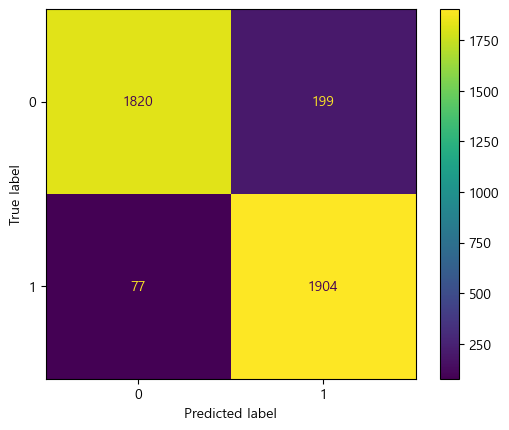

In [178]:
# 오차행렬 계산
cm = confusion_matrix(y_test, lr_test_pred)

# 오차행렬 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
disp.plot()
plt.show()

In [ ]:
"""
전처리한 데이터가 총 4만개로 모델을 돌려보았으나,  심근경색에 Target데이터가 너무 데이터 불균형이(0(걸리지않음 약45000개), 1(걸림 약1300개)) 너무 
심해 모델의 성능이 너무 안좋은 모델이 나왔다. 
이 문제를 해결하기 위해 10년치 데이터를 더 모아 심근경색에 걸린데이터(1에대한 데이터)만 뽑아서 전처리 후 데이터를 합쳐 총 0(약45000개), 1(약2700개)로
데이터를 조금 늘리고 각 데이터들에 대한 균형을 1만개로 통일 시켰다(1에 대한 데이터는 랜덤으로 샘플링, 0에 대한 데이터는 오버샘플링으로 1만개만듬)
이렇게 데이터를 1:1비율로 맞추고 모델을 만들었더니 아주 괜찮은 모델이 나왔다. 
"""

In [185]:
### 최고의 모델 찾기
case = ["StandardScaler", "MinMaxScaler"]
best_models = {}

rf_c = RandomForestClassifier()
ex_c = ExtraTreesClassifier()
gb_c = GradientBoostingClassifier()
hgb_c = HistGradientBoostingClassifier()
xgb_c = XGBClassifier()

class_list = [rf_c, ex_c, gb_c, hgb_c, xgb_c]

# - 랜덤포레스트, 엑스트라트리, 그레디언트부스트
a_model = {}
a_model["min_samples_leaf"] = [1, 2, 4]
a_model["min_samples_split"] = [2, 5]
a_model["max_depth"] = [None, 10]
a_model["n_estimators"] = [50, 100]

# - 히스트그레디언트부스트 
hist_model = {}
hist_model["min_samples_leaf"] = [1, 2, 4]
hist_model["max_depth"] = [None, 10] 
hist_model["max_iter"] = [50, 100]

# - 엑스지부스트
xgb_model = {}
xgb_model["min_child_weight"] = [1, 2, 4] 
xgb_model["max_depth"] = [None, 10]
xgb_model["n_estimators"] = [50, 100]

# - cv클래스 값 정의
cv = 5 
refit = "accuracy"
scoring = "accuracy"

for i in case:
    if i == "StandardScaler":
        train_scaler = X_train
        test_scaler = X_test
        
            
    elif i =="MinMaxScaler":
        train_scaler = X_train
        test_scaler = X_test

    for j in class_list:
        if j in (rf_c, ex_c, gb_c):
            grid_search_model = GridSearchCV(j, a_model, scoring = scoring, refit = refit, cv = cv)
            grid_search_model.fit(train_scaler, y_train)
            
        elif j == hgb_c:
            grid_search_model = GridSearchCV(j, hist_model, scoring = scoring, refit = refit, cv = cv)
            grid_search_model.fit(train_scaler, y_train)

        elif j == xgb_c:
            grid_search_model = GridSearchCV(j, xgb_model, scoring = scoring, refit = refit, cv = cv)
            grid_search_model.fit(train_scaler, y_train)

        print(f"{j.__class__.__name__}의 최적의 하이퍼파라메터 : {grid_search_model.best_params_} {i}")
        
        best_model = grid_search_model.best_estimator_
        
        best_models[j.__class__.__name__] = best_model
        
        best_model.fit(train_scaler, y_train)

        best_model_train_score = best_model.score(train_scaler, y_train)
        best_model_test_score = best_model.score(test_scaler, y_test)
        
        best_model_train_pred = best_model.predict(train_scaler)
        best_model_test_pred = best_model.predict(test_scaler)

        overfit = best_model_train_score - best_model_test_score

        acc_train = accuracy_score(y_train, best_model_train_pred)
        acc_test = accuracy_score(y_test, best_model_test_pred)
    
        acc = acc_train - acc_test
        pre = precision_score(y_test, best_model_test_pred)
        rec = recall_score(y_test, best_model_test_pred)
        f1 = f1_score(y_test, best_model_test_pred)
        
        print(f"과대/과소 적합 확인 {overfit}")
        print(f"(훈련-검증)정확도 : {acc:.4f} \n정밀도 : {pre:.4f} \n재현율 : {rec:.4f} \nF1-Score : {f1:.4f}")

        


RandomForestClassifier의 최적의 하이퍼파라메터 : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100} StandardScaler
과대/과소 적합 확인 0.044749999999999956
(훈련-검증)정확도 : 0.0447 
정밀도 : 0.9323 
재현율 : 0.9808 
F1-Score : 0.9560
ExtraTreesClassifier의 최적의 하이퍼파라메터 : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100} StandardScaler
과대/과소 적합 확인 0.02849999999999997
(훈련-검증)정확도 : 0.0285 
정밀도 : 0.9551 
재현율 : 0.9889 
F1-Score : 0.9717
GradientBoostingClassifier의 최적의 하이퍼파라메터 : {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 100} StandardScaler
과대/과소 적합 확인 0.04225000000000001
(훈련-검증)정확도 : 0.0423 
정밀도 : 0.9356 
재현율 : 0.9823 
F1-Score : 0.9584
HistGradientBoostingClassifier의 최적의 하이퍼파라메터 : {'max_depth': None, 'max_iter': 100, 'min_samples_leaf': 4} StandardScaler
과대/과소 적합 확인 0.054187499999999944
(훈련-검증)정확도 : 0.0542 
정밀도 : 0.8675 
재현율 : 0.9157 
F1-Score : 0.8910
XGBClassifier의 최적의 하이퍼파라메터 : {'max_depth': 10, 'min_chil

In [ ]:
# roc curve 그래프 그리기
# 모델에 대한 시각화 자료 만들기(엑스트라부스트)
# 모델 뽑기

In [189]:
extramodel = ExtraTreesClassifier(n_estimators = 50, max_depth = None, min_samples_split = 2, min_samples_leaf = 1)
# 학습
extramodel.fit(X_train_scale, y_train)

# 확률 예측
lr_test_pred = model.predict(X_test_scale)
y_probs = model.predict_proba(X_test_scale)[:, 1]

print(classification_report(y_test, lr_test_pred))

              precision    recall  f1-score   support

         0.0       0.96      0.90      0.93      2019
         1.0       0.91      0.96      0.93      1981

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000



In [194]:
save_path = "./model/heart_predict_model.pkl"
joblib.dump(extramodel, save_path)

['./model/heart_predict_model.pkl']

In [80]:
target.value_counts()

DI4_dg
0.0    45500
1.0     1387
Name: count, dtype: int64